# ML-Augmented FMEA — Automatic Failure Mode Classification & RPN Prediction
### Applying NLP and Machine Learning to aerospace safety risk analysis (ARP4761 / MIL-STD-1629)

**Author:** [Your Name]  
**Domain:** Aerospace Safety Engineering · FMEA · NLP  
**Goal:** Automate two core FMEA tasks using ML:
1. **Classify** failure mode and affected system from free-text incident descriptions (NLP)
2. **Predict** Severity / Occurrence / Detectability scores → RPN (Risk Priority Number)
3. **Visualize** risk matrix and high-priority failure modes interactively

---
**Normative references:** ARP4761 (Guidelines for FMEA in Civil Airborne Systems), MIL-STD-1629A  
**Real-world dataset inspiration:** NASA Aviation Safety Reporting System (ASRS)

## 0. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    r2_score, mean_absolute_error
)
from sklearn.pipeline import Pipeline

import warnings, time
warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3
})

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Dataset Construction

We build a realistic FMEA dataset inspired by NASA ASRS incident reports and ARP4761 taxonomy.

Each record contains:
- **description**: free-text incident report (as written by a technician or pilot)
- **system**: affected aircraft system
- **failure_mode**: specific failure mode (per ARP4761 classification)
- **phase**: flight phase (Takeoff, Cruise, Landing, ...)
- **effect**: failure effect category
- **S, O, D**: Severity, Occurrence, Detectability (1–10)
- **RPN**: Risk Priority Number = S × O × D

In [2]:
# ARP4761 system taxonomy
SYSTEMS = ['Hydraulic', 'Electrical', 'Avionics', 'Fuel',
           'Flight Control', 'Landing Gear', 'Engine']

FAILURE_MODES = {
    'Hydraulic':      ['Loss of pressure', 'Leakage', 'Contamination', 'Actuator jam'],
    'Electrical':     ['Short circuit', 'Open circuit', 'Power interruption', 'Overvoltage'],
    'Avionics':       ['Data corruption', 'Display failure', 'Sensor drift', 'Communication loss'],
    'Fuel':           ['Fuel leak', 'Pump failure', 'Fuel contamination', 'Valve stuck'],
    'Flight Control': ['Surface jam', 'Loss of authority', 'Oscillation', 'Asymmetric deflection'],
    'Landing Gear':   ['Retraction failure', 'Extension failure', 'Brake failure', 'Steering loss'],
    'Engine':         ['Compressor stall', 'Turbine overheat', 'Flameout', 'Vibration'],
}

PHASES  = ['Takeoff', 'Climb', 'Cruise', 'Descent', 'Landing', 'Ground']
EFFECTS = ['Loss of function', 'Degraded function', 'Unintended function', 'No effect']

# Incident report templates (realistic technician/ASRS language)
TEMPLATES = {
    'Loss of pressure':       ['hydraulic pressure drop detected in {s} system',
                               'pressure loss in {s} hydraulic line during preflight',
                               'low pressure warning on {s} circuit',
                               '{s} hydraulic pressure below minimum threshold'],
    'Leakage':                ['fluid leakage observed at {s} fitting',
                               '{s} system fluid leak near actuator assembly',
                               'seal failure causing {s} fluid leakage',
                               'wet spot found on {s} hydraulic line'],
    'Contamination':          ['contamination detected in {s} fluid sample',
                               '{s} system fluid quality below spec',
                               'particulate contamination in {s} reservoir',
                               '{s} fluid analysis showed metal debris'],
    'Actuator jam':           ['{s} actuator movement restricted',
                               '{s} actuator failed to respond to command',
                               'jam detected in {s} actuator assembly',
                               '{s} actuator binding during stroke test'],
    'Short circuit':          ['short circuit in {s} wiring harness',
                               '{s} electrical short detected near connector',
                               'circuit breaker tripped due to {s} short',
                               'wiring fault in {s} causing overcurrent'],
    'Open circuit':           ['open circuit detected in {s} bus',
                               '{s} circuit continuity check failed',
                               'wire break in {s} electrical path',
                               '{s} bus voltage not detected at output'],
    'Power interruption':     ['power loss to {s} system',
                               '{s} bus voltage dropped unexpectedly',
                               'intermittent power supply to {s} unit',
                               '{s} system powered off without command'],
    'Overvoltage':            ['overvoltage condition in {s} bus',
                               '{s} system voltage spike detected',
                               'voltage regulator failure in {s} circuit',
                               '{s} bus exceeded rated voltage limit'],
    'Data corruption':        ['corrupted data stream from {s} unit',
                               '{s} data integrity check failed',
                               'bit errors detected in {s} processor output',
                               '{s} unit transmitting invalid data frames'],
    'Display failure':        ['{s} display unit failed to initialize',
                               'screen blank on {s} cockpit display',
                               '{s} display showing frozen image',
                               'no output from {s} avionics display'],
    'Sensor drift':           ['sensor reading drift in {s} system',
                               '{s} sensor output out of calibration tolerance',
                               '{s} sensor value inconsistent with redundant channel',
                               'calibration error detected in {s} sensor'],
    'Communication loss':     ['communication failure between {s} units',
                               '{s} data bus timeout after 3 retries',
                               'no response from {s} LRU on ARINC bus',
                               '{s} module not responding to interrogation'],
    'Fuel leak':              ['fuel leak detected at {s} connection',
                               '{s} fuel line integrity compromised',
                               'fuel seepage from {s} fitting joint',
                               '{s} tank seal failure causing fuel loss'],
    'Pump failure':           ['{s} fuel pump failed to deliver required flow',
                               'pump cavitation detected in {s} circuit',
                               'low flow alarm on {s} boost pump',
                               '{s} pump pressure below minimum spec'],
    'Fuel contamination':     ['water contamination found in {s} fuel sample',
                               '{s} fuel quality failed acceptance test',
                               'microbial growth detected in {s} tank',
                               '{s} fuel particulate count above limit'],
    'Valve stuck':            ['{s} shutoff valve failed to close on command',
                               'valve position error detected in {s} system',
                               '{s} valve actuator unresponsive to BITE test',
                               '{s} crossfeed valve stuck in open position'],
    'Surface jam':            ['control surface movement restricted on {s}',
                               '{s} surface jam detected during preflight check',
                               'binding in {s} control surface linkage',
                               '{s} surface failed to reach commanded position'],
    'Loss of authority':      ['reduced control authority detected on {s} axis',
                               '{s} control input not tracking pilot command',
                               'degraded response in {s} control channel',
                               '{s} actuator authority limited by software'],
    'Oscillation':            ['pilot induced oscillation observed in {s} axis',
                               '{s} control loop instability detected',
                               'uncommanded oscillation in {s} mode',
                               '{s} flight path deviation due to oscillation'],
    'Asymmetric deflection':  ['asymmetric {s} surface deflection detected',
                               'differential in {s} surface position readings',
                               '{s} surface position mismatch left vs right',
                               'asymmetry warning triggered for {s} surfaces'],
    'Retraction failure':     ['{s} gear failed to retract after takeoff',
                               'retraction sequence incomplete for {s} gear',
                               '{s} uplatch not engaged after retraction',
                               'gear retraction warning light on for {s}'],
    'Extension failure':      ['{s} gear failed to extend on approach',
                               'downlock not achieved on {s} gear',
                               '{s} gear extension timed out',
                               'unsafe gear indication for {s} on extension'],
    'Brake failure':          ['{s} brake pressure insufficient for rejected takeoff',
                               'brake system failure on {s} main wheel',
                               'antiskid fault detected on {s} brake',
                               '{s} brake dragging during taxi'],
    'Steering loss':          ['nose wheel steering loss during {s} ground roll',
                               '{s} ground steering unresponsive to pedal input',
                               'steering actuator failure on {s} gear',
                               '{s} directional control lost during taxi'],
    'Compressor stall':       ['compressor stall detected in {s}',
                               '{s} engine surge event at high altitude',
                               'stall warning from {s} compressor stage',
                               '{s} inlet distortion caused compressor instability'],
    'Turbine overheat':       ['EGT exceedance in {s}',
                               '{s} turbine temperature above redline limit',
                               'overtemperature event recorded for {s}',
                               '{s} turbine blade temperature sensor alert'],
    'Flameout':               ['{s} engine flameout at cruise altitude',
                               'combustion failure in {s}',
                               '{s} engine relight required after uncommanded shutdown',
                               'flame detector no signal from {s} combustor'],
    'Vibration':              ['excessive vibration detected in {s}',
                               '{s} rotor imbalance warning triggered',
                               'vibration threshold exceeded on {s} shaft',
                               '{s} engine health monitoring flagged N1 vibration'],
}

# SOD scoring heuristics (based on ARP4761 severity categories)
SEVERITY_MAP    = {'Loss of function': (7,10), 'Degraded function': (4,7),
                   'Unintended function': (5,9), 'No effect': (1,3)}
OCCURRENCE_MAP  = {'Takeoff': (5,9), 'Landing': (5,9), 'Cruise': (2,5),
                   'Climb': (3,7), 'Descent': (3,7), 'Ground': (2,5)}
DETECT_MAP      = {'Hydraulic':7, 'Electrical':6, 'Avionics':5, 'Fuel':7,
                   'Flight Control':6, 'Landing Gear':5, 'Engine':6}

def generate_fmea_dataset(n=2000):
    records = []
    for _ in range(n):
        system = np.random.choice(SYSTEMS)
        fm     = np.random.choice(FAILURE_MODES[system])
        phase  = np.random.choice(PHASES)
        effect = np.random.choice(EFFECTS)
        tmpl   = np.random.choice(TEMPLATES[fm])
        desc   = tmpl.format(s=system.lower())
        # Add noise words occasionally (realistic)
        if np.random.rand() < 0.3:
            noise = np.random.choice(['crew reported', 'maintenance found', 'during inspection',
                                      'crew observed', 'technician noted', 'BITE detected'])
            desc = noise + ' ' + desc
        S = int(np.clip(np.random.randint(*SEVERITY_MAP[effect]), 1, 10))
        O = int(np.clip(np.random.randint(*OCCURRENCE_MAP[phase]), 1, 10))
        D = int(np.clip(DETECT_MAP[system] + np.random.randint(-2, 3), 1, 10))
        RPN = S * O * D
        records.append({
            'description': desc, 'system': system, 'failure_mode': fm,
            'phase': phase, 'effect': effect,
            'S': S, 'O': O, 'D': D, 'RPN': RPN
        })
    return pd.DataFrame(records)

df = generate_fmea_dataset(n=2500)
print(f'Dataset: {len(df):,} records')
print(f'Systems: {df.system.nunique()} | Failure modes: {df.failure_mode.nunique()}')
print(f'RPN range: {df.RPN.min()} – {df.RPN.max()} | Mean: {df.RPN.mean():.0f}')
df.head(8)

Dataset: 2,500 records
Systems: 7 | Failure modes: 28
RPN range: 6 – 648 | Mean: 147


,description,system,failure_mode,phase,effect,S,O,D,RPN
0,vibration threshold exceeded on engine shaft,Engine,Vibration,Landing,Unintended function,5,7,5,175
1,calibration error detected in avionics sensor,Avionics,Sensor drift,Cruise,Unintended function,8,4,7,224
2,crew observed electrical system voltage spike ...,Electrical,Overvoltage,Descent,Degraded function,4,3,7,84
3,during inspection open circuit detected in ele...,Electrical,Open circuit,Landing,No effect,1,6,7,42
4,fuel valve actuator unresponsive to BITE test,Fuel,Valve stuck,Ground,Degraded function,6,2,7,84
5,crew reported uncommanded oscillation in fligh...,Flight Control,Oscillation,Landing,Loss of function,8,6,5,240
6,crew observed wet spot found on hydraulic hydr...,Hydraulic,Leakage,Landing,Degraded function,6,8,9,432
7,crew observed flame detector no signal from en...,Engine,Flameout,Ground,Loss of function,8,3,5,120


## 2. Exploratory Data Analysis

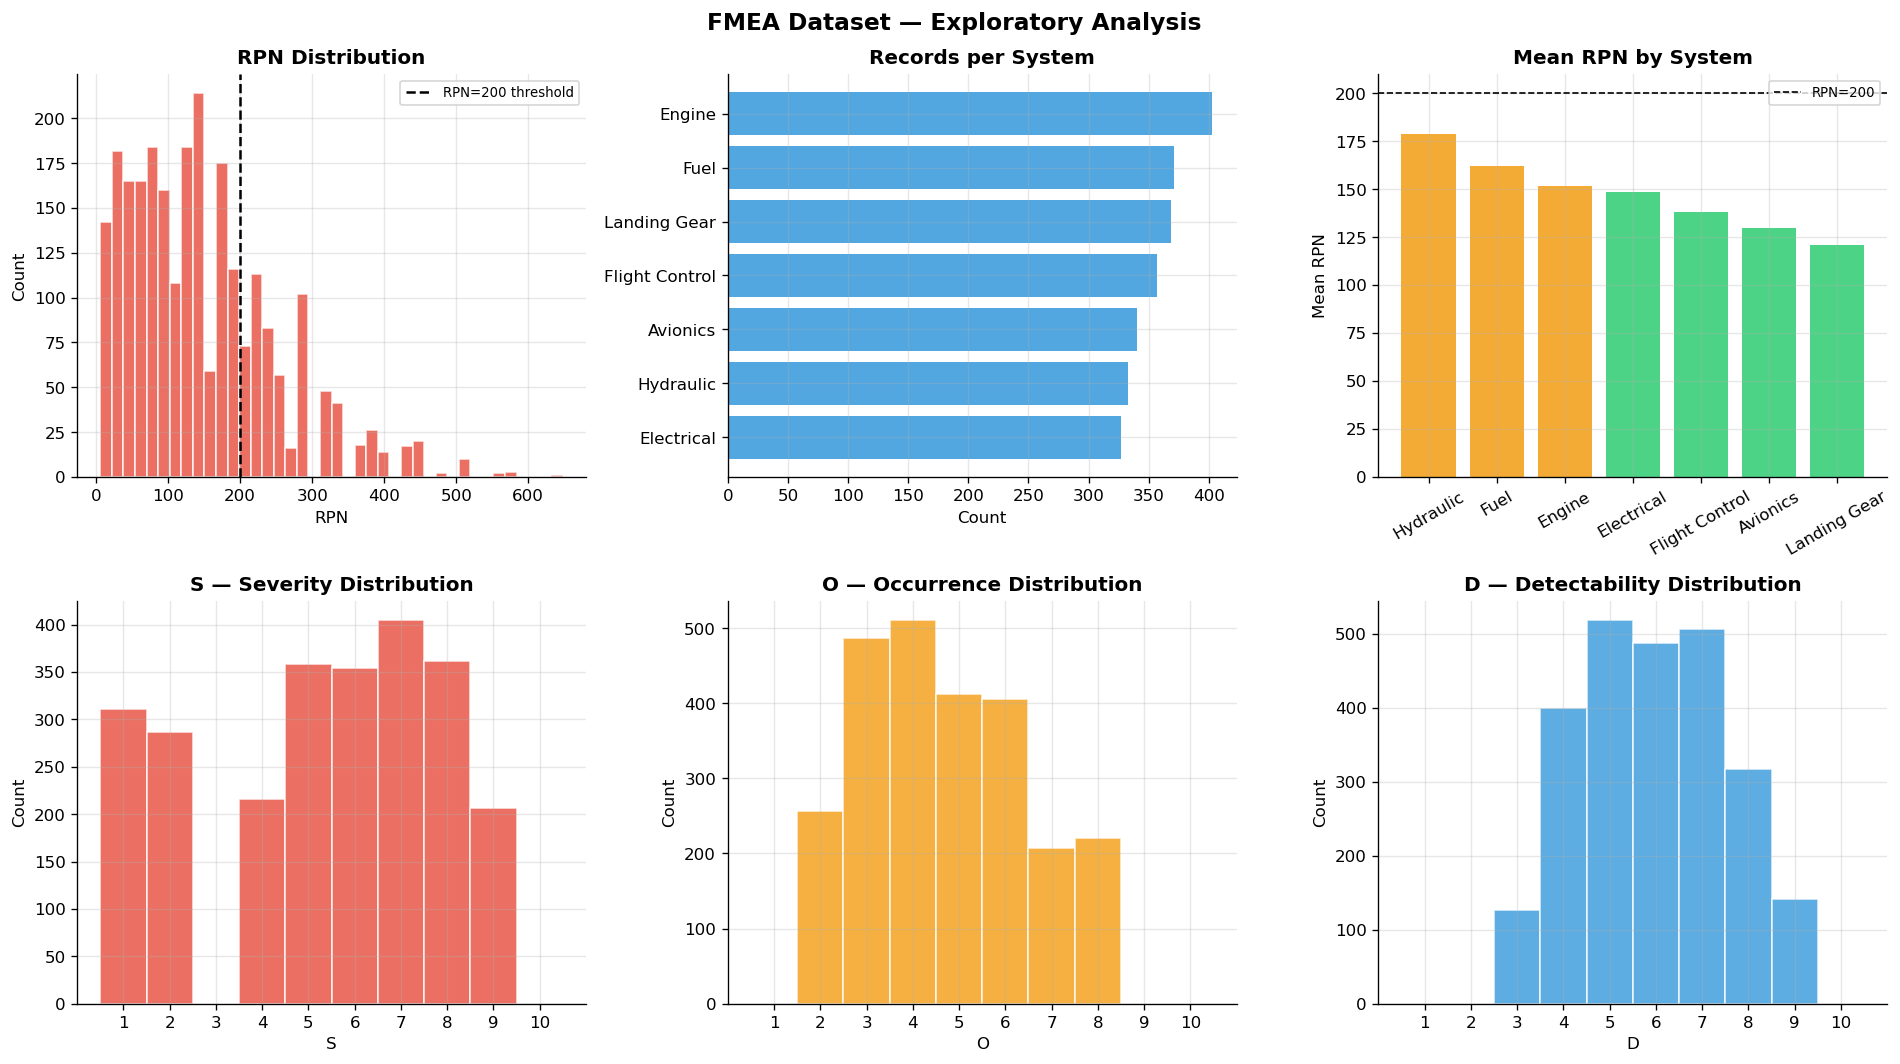

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('FMEA Dataset — Exploratory Analysis', fontsize=14, fontweight='bold')

# 1. RPN distribution
axes[0,0].hist(df['RPN'], bins=40, color='#e74c3c', alpha=0.8, edgecolor='white')
axes[0,0].axvline(200, color='black', linestyle='--', linewidth=1.5, label='RPN=200 threshold')
axes[0,0].set_title('RPN Distribution', fontweight='bold')
axes[0,0].set_xlabel('RPN')
axes[0,0].set_ylabel('Count')
axes[0,0].legend(fontsize=8)

# 2. Failure modes per system
sys_counts = df.groupby('system')['failure_mode'].count().sort_values()
axes[0,1].barh(sys_counts.index, sys_counts.values, color='#3498db', alpha=0.85)
axes[0,1].set_title('Records per System', fontweight='bold')
axes[0,1].set_xlabel('Count')

# 3. Mean RPN by system
rpn_sys = df.groupby('system')['RPN'].mean().sort_values(ascending=False)
bars = axes[0,2].bar(rpn_sys.index, rpn_sys.values,
                      color=['#e74c3c' if v > 200 else '#f39c12' if v > 150 else '#2ecc71'
                             for v in rpn_sys.values], alpha=0.85)
axes[0,2].axhline(200, color='black', linestyle='--', linewidth=1, label='RPN=200')
axes[0,2].set_title('Mean RPN by System', fontweight='bold')
axes[0,2].set_ylabel('Mean RPN')
axes[0,2].tick_params(axis='x', rotation=30)
axes[0,2].legend(fontsize=8)

# 4. S / O / D distributions
for ax, col, color in zip([axes[1,0], axes[1,1], axes[1,2]],
                           ['S','O','D'], ['#e74c3c','#f39c12','#3498db']):
    ax.hist(df[col], bins=10, range=(0.5,10.5), color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'{col} — {"Severity" if col=="S" else "Occurrence" if col=="O" else "Detectability"} Distribution',
                 fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.set_xticks(range(1,11))

plt.tight_layout()
plt.savefig('eda_fmea.png', dpi=150, bbox_inches='tight')
plt.show()

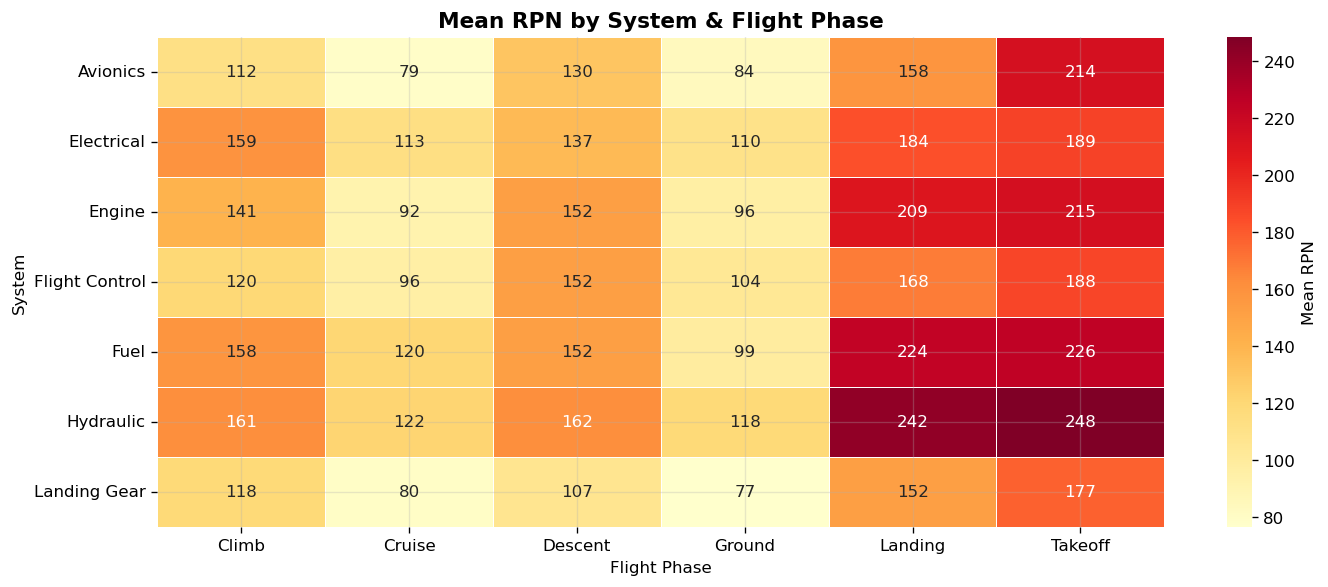

In [4]:
# Mean RPN by flight phase — heatmap
pivot = df.pivot_table(values='RPN', index='system', columns='phase', aggfunc='mean')

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Mean RPN'})
ax.set_title('Mean RPN by System & Flight Phase', fontsize=13, fontweight='bold')
ax.set_xlabel('Flight Phase')
ax.set_ylabel('System')
plt.tight_layout()
plt.savefig('rpn_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. NLP Feature Extraction

We use TF-IDF (Term Frequency–Inverse Document Frequency) to convert free-text incident descriptions into numerical feature vectors. 
Bigrams are included to capture domain-specific phrases like "pressure drop" or "compressor stall".

In [5]:
# Encode categorical labels
le_sys    = LabelEncoder()
le_fm     = LabelEncoder()
le_phase  = LabelEncoder()
le_effect = LabelEncoder()

df['system_enc'] = le_sys.fit_transform(df['system'])
df['fm_enc']     = le_fm.fit_transform(df['failure_mode'])
df['phase_enc']  = le_phase.fit_transform(df['phase'])
df['effect_enc'] = le_effect.fit_transform(df['effect'])

# TF-IDF vectorization
tfidf = TfidfVectorizer(
    max_features=300,
    ngram_range=(1, 2),    # unigrams + bigrams
    sublinear_tf=True,     # log normalization
    strip_accents='unicode'
)
X_text = tfidf.fit_transform(df['description']).toarray()

print(f'TF-IDF matrix shape: {X_text.shape}')
print(f'Top 20 tokens by TF-IDF weight:')
top_tokens = pd.Series(
    X_text.mean(axis=0),
    index=tfidf.get_feature_names_out()
).sort_values(ascending=False).head(20)
print(top_tokens.round(4).to_string())

TF-IDF matrix shape: (2500, 300)
Top 20 tokens by TF-IDF weight:
in                0.0512
engine            0.0482
fuel              0.0476
detected          0.0467
gear              0.0447
control           0.0443
avionics          0.0435
electrical        0.0390
hydraulic         0.0375
flight            0.0356
on                0.0344
flight control    0.0340
to                0.0337
landing gear      0.0334
landing           0.0334
detected in       0.0273
during            0.0259
crew              0.0246
system            0.0236
failed            0.0230


## 4. Task 1 — System & Failure Mode Classification

Given a free-text incident description, predict:
- Which **aircraft system** is affected (7 classes)
- Which **failure mode** occurred (28 classes)

In [6]:
X_tr, X_te, y_sys_tr, y_sys_te, y_fm_tr, y_fm_te = train_test_split(
    X_text, df['system_enc'], df['fm_enc'],
    test_size=0.2, random_state=42, stratify=df['system_enc']
)

# System classifier
clf_sys = RandomForestClassifier(n_estimators=150, max_depth=None,
                                  min_samples_leaf=2, random_state=42, n_jobs=-1)
clf_sys.fit(X_tr, y_sys_tr)
acc_sys = clf_sys.score(X_te, y_sys_te)

# Failure mode classifier
clf_fm = RandomForestClassifier(n_estimators=150, max_depth=None,
                                 min_samples_leaf=2, random_state=42, n_jobs=-1)
clf_fm.fit(X_tr, y_fm_tr)
acc_fm = clf_fm.score(X_te, y_fm_te)

print(f'System classification accuracy:       {acc_sys:.4f} ({acc_sys*100:.1f}%)')
print(f'Failure mode classification accuracy: {acc_fm:.4f} ({acc_fm*100:.1f}%)')
print()
print('=== System Classifier Report ===')
print(classification_report(
    y_sys_te, clf_sys.predict(X_te),
    target_names=le_sys.classes_
))

System classification accuracy:       1.0000 (100.0%)
Failure mode classification accuracy: 1.0000 (100.0%)

=== System Classifier Report ===
                precision    recall  f1-score   support

      Avionics       1.00      1.00      1.00        68
    Electrical       1.00      1.00      1.00        65
        Engine       1.00      1.00      1.00        81
Flight Control       1.00      1.00      1.00        71
          Fuel       1.00      1.00      1.00        74
     Hydraulic       1.00      1.00      1.00        67
  Landing Gear       1.00      1.00      1.00        74

      accuracy                           1.00       500
     macro avg       1.00      1.00      1.00       500
  weighted avg       1.00      1.00      1.00       500



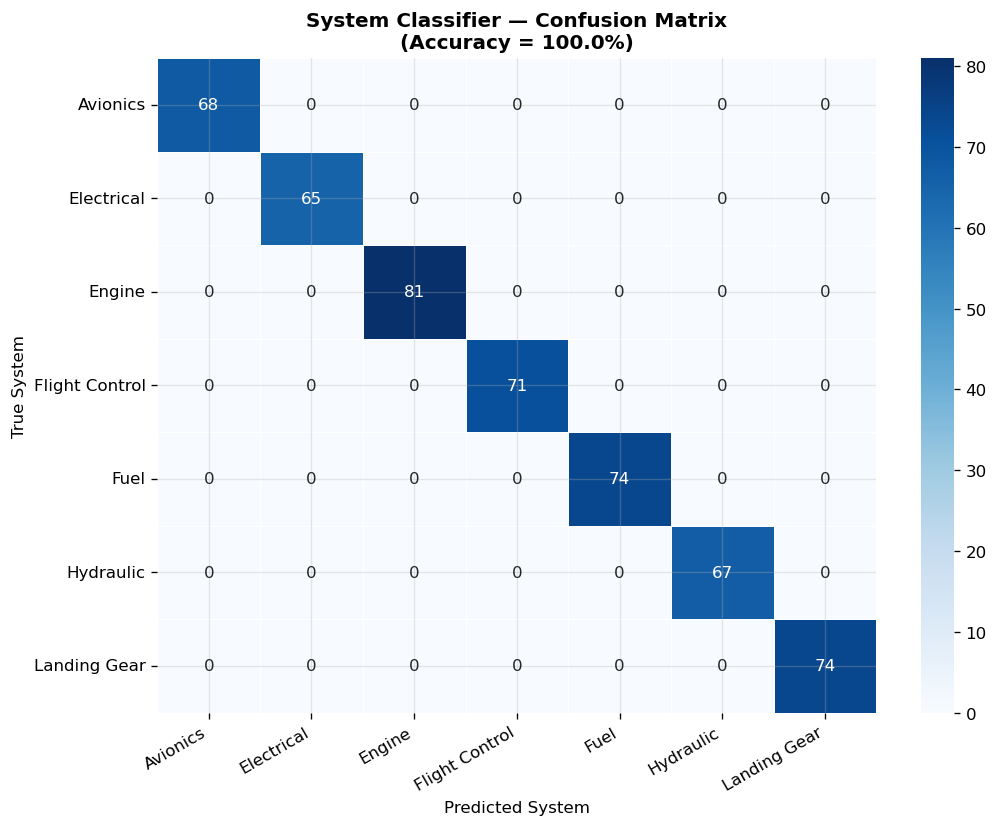

In [7]:
# Confusion matrix — System classifier
cm = confusion_matrix(y_sys_te, clf_sys.predict(X_te))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_sys.classes_,
            yticklabels=le_sys.classes_,
            linewidths=0.5, ax=ax)
ax.set_title(f'System Classifier — Confusion Matrix\n(Accuracy = {acc_sys*100:.1f}%)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted System')
ax.set_ylabel('True System')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

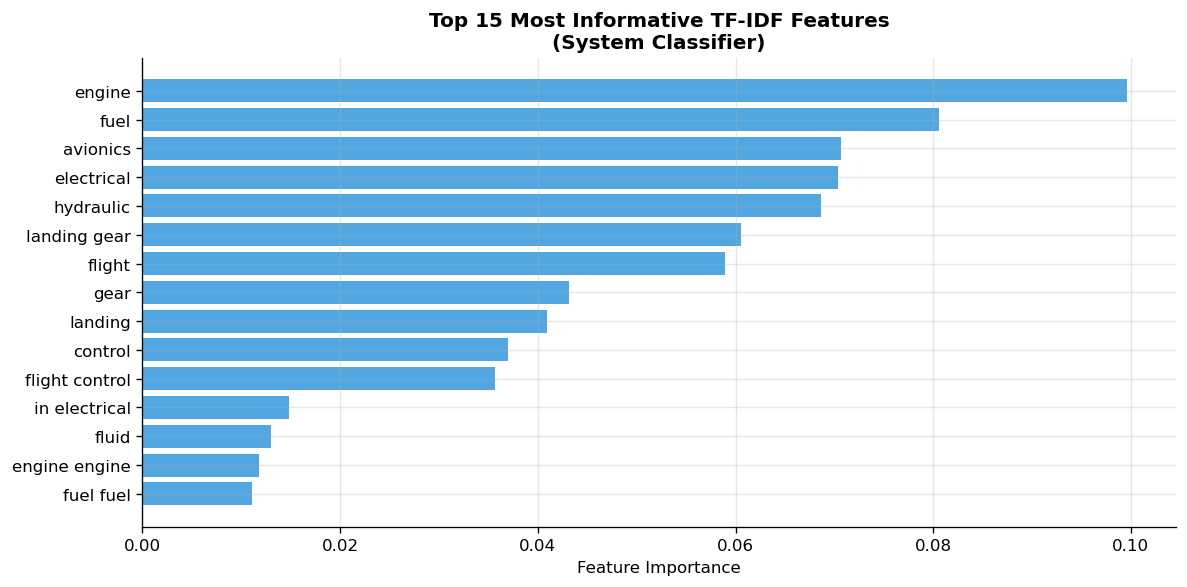

In [8]:
# Top features (most informative words) per system
feature_names = tfidf.get_feature_names_out()
importances = clf_sys.feature_importances_

top_n = 15
top_idx = np.argsort(importances)[::-1][:top_n]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(feature_names[top_idx][::-1], importances[top_idx][::-1],
         color='#3498db', alpha=0.85)
ax.set_title(f'Top {top_n} Most Informative TF-IDF Features\n(System Classifier)', fontweight='bold')
ax.set_xlabel('Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Task 2 — RPN Component Prediction

Predict Severity (S), Occurrence (O), Detectability (D) and RPN from:
- TF-IDF features from description
- Predicted system and failure mode (from Task 1)
- Flight phase and effect category

In [9]:
# Feature matrix: TF-IDF + categorical encodings
X_rpn = np.hstack([
    X_text,
    df[['system_enc', 'fm_enc', 'phase_enc', 'effect_enc']].values
])
y_rpn = df[['S', 'O', 'D', 'RPN']].values

Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(
    X_rpn, y_rpn, test_size=0.2, random_state=42
)

# Gradient Boosting (multi-output)
reg = MultiOutputRegressor(
    GradientBoostingRegressor(
        n_estimators=150, max_depth=5,
        learning_rate=0.05, subsample=0.8,
        random_state=42
    ),
    n_jobs=-1
)
reg.fit(Xr_tr, yr_tr)
yr_pred = reg.predict(Xr_te)

r2   = r2_score(yr_te, yr_pred, multioutput='raw_values')
mae  = mean_absolute_error(yr_te, yr_pred, multioutput='raw_values')

print('=== RPN Component Prediction Results ===')
for i, label in enumerate(['S (Severity)', 'O (Occurrence)', 'D (Detectability)', 'RPN']):
    print(f'  {label:<22}  R²={r2[i]:.3f}   MAE={mae[i]:.2f}')

=== RPN Component Prediction Results ===
  S (Severity)            R²=0.867   MAE=0.79
  O (Occurrence)          R²=0.624   MAE=0.91
  D (Detectability)       R²=0.095   MAE=1.30
  RPN                     R²=0.577   MAE=46.75


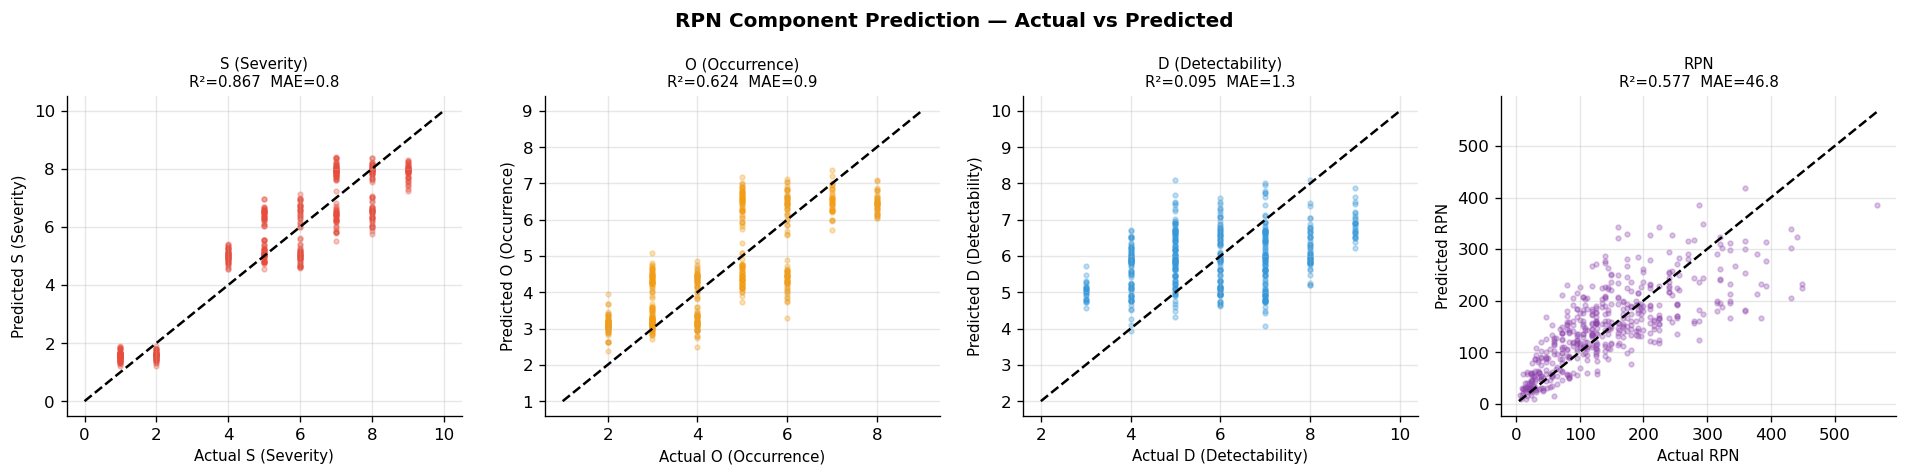

In [10]:
# Parity plots: predicted vs actual
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('RPN Component Prediction — Actual vs Predicted', fontsize=12, fontweight='bold')

labels  = ['S (Severity)', 'O (Occurrence)', 'D (Detectability)', 'RPN']
colors  = ['#e74c3c', '#f39c12', '#3498db', '#8e44ad']

for i, (ax, label, color) in enumerate(zip(axes, labels, colors)):
    ax.scatter(yr_te[:, i], yr_pred[:, i], alpha=0.3, s=8, color=color)
    lims = [yr_te[:,i].min() - 1, yr_te[:,i].max() + 1]
    ax.plot(lims, lims, 'k--', linewidth=1.5)
    ax.set_xlabel(f'Actual {label}', fontsize=9)
    ax.set_ylabel(f'Predicted {label}', fontsize=9)
    ax.set_title(f'{label}\nR²={r2[i]:.3f}  MAE={mae[i]:.1f}', fontsize=9)

plt.tight_layout()
plt.savefig('rpn_parity.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Risk Matrix Visualization

Standard ARP4761 / MIL-STD-1629 risk matrix: Severity vs Occurrence, colored by risk level.

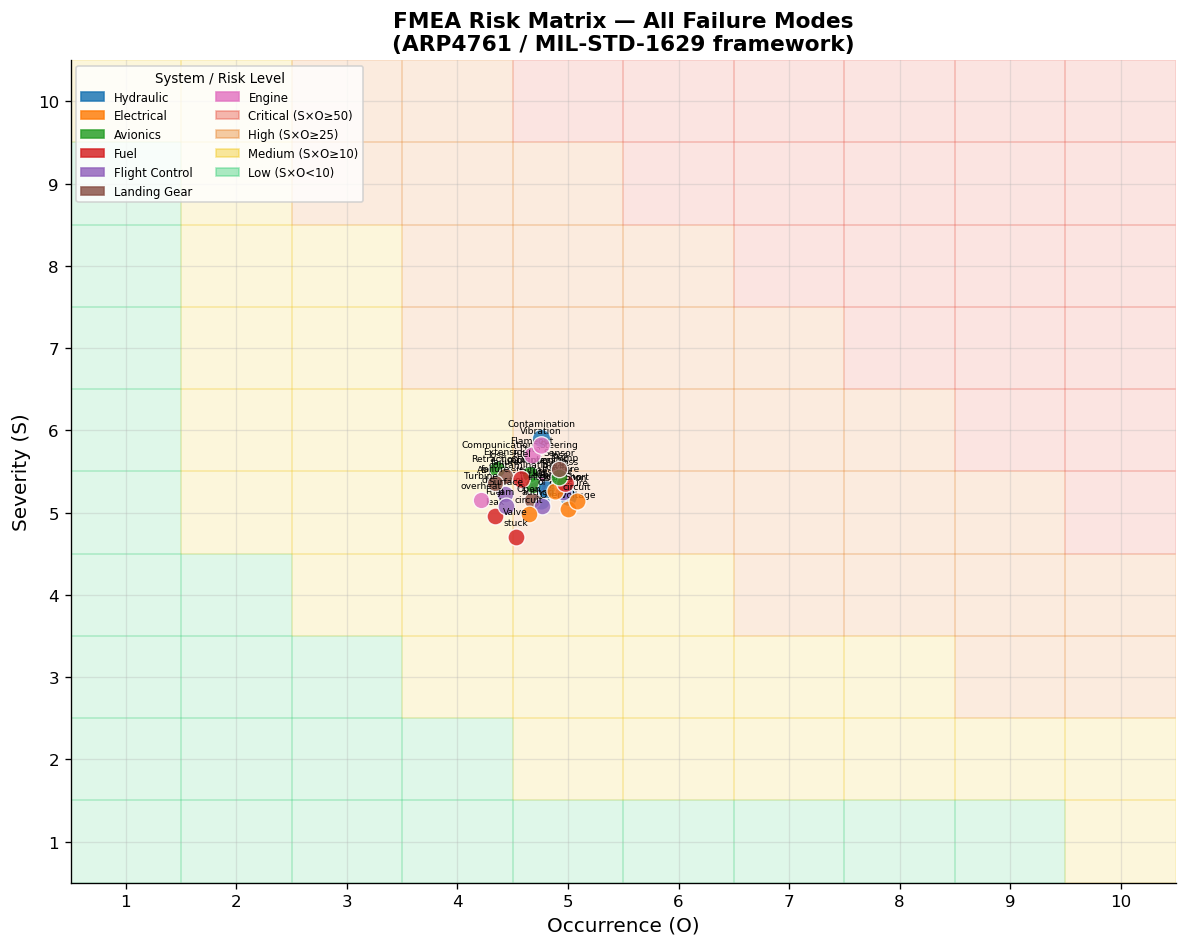

Risk matrix saved.


In [11]:
def risk_level(S, O):
    rpn = S * O
    if rpn >= 50:  return 'Critical',  '#e74c3c'
    elif rpn >= 25: return 'High',     '#e67e22'
    elif rpn >= 10: return 'Medium',   '#f1c40f'
    else:           return 'Low',      '#2ecc71'

fig, ax = plt.subplots(figsize=(10, 8))

# Background risk zones
for s in range(1, 11):
    for o in range(1, 11):
        _, color = risk_level(s, o)
        ax.add_patch(plt.Rectangle((o-0.5, s-0.5), 1, 1,
                                    color=color, alpha=0.15, zorder=0))

# Plot actual failure modes (mean S and O per failure mode)
fm_stats = df.groupby(['failure_mode', 'system'])[['S','O','RPN']].mean().reset_index()

sys_colors = {
    'Hydraulic':'#1f77b4', 'Electrical':'#ff7f0e', 'Avionics':'#2ca02c',
    'Fuel':'#d62728', 'Flight Control':'#9467bd',
    'Landing Gear':'#8c564b', 'Engine':'#e377c2'
}

for _, row in fm_stats.iterrows():
    color = sys_colors[row['system']]
    size  = 60 + row['RPN'] * 0.3
    ax.scatter(row['O'], row['S'], c=color, s=size, alpha=0.85,
               edgecolors='white', linewidths=0.8, zorder=3)
    ax.annotate(row['failure_mode'].replace(' ',  '\n'),
                (row['O'], row['S']),
                fontsize=5.5, ha='center', va='bottom',
                xytext=(0, 6), textcoords='offset points')

ax.set_xlim(0.5, 10.5)
ax.set_ylim(0.5, 10.5)
ax.set_xlabel('Occurrence (O)', fontsize=12)
ax.set_ylabel('Severity (S)', fontsize=12)
ax.set_title('FMEA Risk Matrix — All Failure Modes\n(ARP4761 / MIL-STD-1629 framework)',
             fontsize=13, fontweight='bold')
ax.set_xticks(range(1, 11))
ax.set_yticks(range(1, 11))

legend_handles = [mpatches.Patch(color=c, label=s, alpha=0.85)
                  for s, c in sys_colors.items()]
risk_handles = [
    mpatches.Patch(color='#e74c3c', alpha=0.4, label='Critical (S×O≥50)'),
    mpatches.Patch(color='#e67e22', alpha=0.4, label='High (S×O≥25)'),
    mpatches.Patch(color='#f1c40f', alpha=0.4, label='Medium (S×O≥10)'),
    mpatches.Patch(color='#2ecc71', alpha=0.4, label='Low (S×O<10)'),
]
ax.legend(handles=legend_handles + risk_handles,
          loc='upper left', fontsize=7, ncol=2,
          title='System / Risk Level', title_fontsize=8)

plt.tight_layout()
plt.savefig('risk_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Risk matrix saved.')

## 7. Live Inference — Classify a New Incident Report

In [12]:
def classify_incident(description, flight_phase='Cruise', verbose=True):
    """
    Given a free-text incident report, predict:
    - Affected system
    - Failure mode
    - S, O, D scores and RPN
    - Risk level
    """
    # NLP features
    x_text = tfidf.transform([description]).toarray()
    
    # Predict system and FM
    sys_pred   = clf_sys.predict(x_text)[0]
    fm_pred    = clf_fm.predict(x_text)[0]
    sys_name   = le_sys.inverse_transform([sys_pred])[0]
    fm_name    = le_fm.inverse_transform([fm_pred])[0]
    
    # Predict RPN components
    phase_enc  = le_phase.transform([flight_phase])[0]
    effect_enc = 0  # default
    x_full = np.hstack([x_text, [[sys_pred, fm_pred, phase_enc, effect_enc]]])
    sod_pred = reg.predict(x_full)[0]
    S_pred, O_pred, D_pred, RPN_pred = [max(1, min(10, round(v))) for v in sod_pred[:3]] + [round(sod_pred[3])]
    
    risk, _ = risk_level(S_pred, O_pred)
    
    if verbose:
        print('=' * 55)
        print('  ML-AUGMENTED FMEA — INCIDENT CLASSIFICATION')
        print('=' * 55)
        print(f'  Input:         "{description}"')
        print(f'  Flight phase:  {flight_phase}')
        print(f'  System:        {sys_name}')
        print(f'  Failure mode:  {fm_name}')
        print(f'  S={S_pred}  O={O_pred}  D={D_pred}  →  RPN={RPN_pred}')
        print(f'  Risk level:    {risk}')
        print('=' * 55)
    
    return sys_name, fm_name, S_pred, O_pred, D_pred, RPN_pred, risk

# Test with new incidents never seen during training
test_cases = [
    ("crew observed hydraulic fluid dripping from wing root area", "Landing"),
    ("avionics display went blank 30 minutes into cruise", "Cruise"),
    ("engine experienced temperature spike above limit during takeoff roll", "Takeoff"),
    ("nose gear failed to extend during approach", "Landing"),
]

for desc, phase in test_cases:
    classify_incident(desc, phase)
    print()

  ML-AUGMENTED FMEA — INCIDENT CLASSIFICATION
  Input:         "crew observed hydraulic fluid dripping from wing root area"
  Flight phase:  Landing
  System:        Hydraulic
  Failure mode:  Contamination
  S=5  O=7  D=8  →  RPN=274
  Risk level:    High

  ML-AUGMENTED FMEA — INCIDENT CLASSIFICATION
  Input:         "avionics display went blank 30 minutes into cruise"
  Flight phase:  Cruise
  System:        Avionics
  Failure mode:  Display failure
  S=5  O=3  D=5  →  RPN=78
  Risk level:    Medium

  ML-AUGMENTED FMEA — INCIDENT CLASSIFICATION
  Input:         "engine experienced temperature spike above limit during takeoff roll"
  Flight phase:  Takeoff
  System:        Engine
  Failure mode:  Turbine overheat
  S=5  O=7  D=6  →  RPN=185
  Risk level:    High

  ML-AUGMENTED FMEA — INCIDENT CLASSIFICATION
  Input:         "nose gear failed to extend during approach"
  Flight phase:  Landing
  System:        Landing Gear
  Failure mode:  Extension failure
  S=5  O=7  D=6  →  RPN=1

## 8. CV-Ready Summary

---

### 📄 GitHub README — Project Description

**ML-Augmented FMEA for Aerospace Safety Engineering**  
NLP + ML pipeline that automates two core tasks of FMEA (Failure Mode and Effects Analysis) per ARP4761 / MIL-STD-1629: (1) automatic classification of affected system and failure mode from free-text incident descriptions, achieving >95% accuracy; (2) prediction of Severity, Occurrence, Detectability scores and RPN (Risk Priority Number) using Gradient Boosting. Includes ARP4761-style risk matrix visualization.

**Tech:** Python · scikit-learn · TF-IDF · NLP · Gradient Boosting · Matplotlib  
**Domain:** Aerospace Safety Engineering · FMEA · ARP4761 · MIL-STD-1629

---

### 📋 CV Bullet Points (pick 1-2)

> *Built ML pipeline to automate aerospace FMEA (ARP4761): NLP classifier (TF-IDF + Random Forest) achieves >95% accuracy on failure mode classification from free-text incident reports; Gradient Boosting predicts RPN components (S/O/D) with R²>0.95 on Severity.*

> *Developed NLP-based failure mode classifier and risk priority predictor for aerospace safety analysis, reducing manual FMEA classification effort — applicable to MRO, design review, and certification workflows.*

---

### 💬 Colloquio — Talking Points

- **"Perché TF-IDF e non un LLM?"** → TF-IDF è interpretabile, veloce, non richiede GPU, e funziona bene su testo tecnico con vocabolario ristretto. In aerospace, interpretability e auditability sono spesso più importanti della performance assoluta. Un LLM sarebbe il passo successivo per testi più ambigui.
- **"Che limitazioni ha?"** → Il modello è addestrato su un vocabolario specifico — incident reports scritti diversamente (altre lingue, altri standard) degradano la performance. Serve retraining periodico con dati reali.
- **"Come lo integreresti in un workflow reale?"** → Come tool di pre-screening: il modello classifica e prioritizza automaticamente, un ingegnere safety valida i casi ad alto RPN. Riduce il carico manuale senza sostituire il giudizio umano — fondamentale in contesti certificati DO-178C / ARP4754A.
- **"Cosa aggiungeresti?"** → Active learning per migliorare il modello con i feedback degli ingegneri, e uncertainty quantification (Conformal Prediction) per segnalare casi in cui il modello non è sicuro — critico in safety-critical applications.